This notebook is only to see the catboost regressor of the RNAseq z-score combat (withour ridge)

In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import feature_selection as fs
import pickle

2024-05-27 09:45:19.874175: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-27 09:45:19.876930: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-27 09:45:19.905205: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-27 09:45:19.905229: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-27 09:45:19.905875: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
fit=False

In [3]:
eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_SMOTE_8_b.csv")
eigth_bins.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,71-72
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024891,-0.024734,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,72-95
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,50-65
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71-72
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,35-50


In [4]:
eigth_bins["Age"]

0      71-72
1      72-95
2      50-65
3      71-72
4      35-50
       ...  
310    72-95
311    72-95
312    72-95
313    72-95
314    72-95
Name: Age, Length: 315, dtype: object

In [5]:
seq_y_train_cat_a=eigth_bins["Age"]
seq_y_train_a = pd.Series(seq_y_train_cat_a).str.split('-')
seq_y_train_a = seq_y_train_a.apply(lambda x: (int(x[0]) + int(x[1])) / 2)

y_noise = np.random.normal(0, 2, seq_y_train_a.shape)
seq_y_train_a = seq_y_train_a + y_noise
seq_y_train_a = seq_y_train_a.round(0)

dataset = eigth_bins.copy()
dataset["Age"]=seq_y_train_a
dataset.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,73.0
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024891,-0.024734,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,84.0
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,58.0
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,73.0
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,43.0


In [6]:
X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.07)
#random_strength

# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(iterations=4000,
                                  learning_rate=0.005,
                                  depth=4,
                                  random_state=42,
                                  verbose=1,
                                  od_type='Iter',
                                  od_wait=50,
                                  penalties_coefficient=50,
                                  l2_leaf_reg=5,  # Adjust regularization
                                  random_strength=0.7,
                                  ) 

# Fit the model
if fit:
    seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)

In [7]:
if fit:
    # Specify the file path where you want to save the pickle file
    file_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_2_8_seq_regressor.pkl'

    # Save the seq_regressor variable in the pickle file
    with open(file_path, 'wb') as f:
        pickle.dump(seq_regressor, f)
else:

    # Specify the file path where the pickle file is located
    file_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_2_8_seq_regressor.pkl'

    # Load the seq_regressor object from the pickle file
    with open(file_path, 'rb') as f:
        seq_regressor = pickle.load(f)

    # Now you can use the seq_regressor object in your code


In [8]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse

10.307140069658974

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R2
r2 = r2_score(y_test, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 10.307140069658974
RMSE: 3.210473496177624
MAE: 2.482190667362139
R2: 0.9731447402535088


In [10]:
age_ranges_list=[18, 26, 35, 50, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(y_test, age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 4},
 {'label': '26-35', 'range': (26, 35), 'count': 2},
 {'label': '35-50', 'range': (35, 50), 'count': 4},
 {'label': '50-65', 'range': (50, 65), 'count': 3},
 {'label': '65-71', 'range': (65, 71), 'count': 7},
 {'label': '71-72', 'range': (71, 72), 'count': 0},
 {'label': '72-95', 'range': (72, 95), 'count': 3}]

In [11]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[4, 0, 0, 0, 0, 0, 0],
       [0, 2, 0, 0, 0, 0, 0],
       [0, 0, 4, 0, 0, 0, 0],
       [0, 0, 0, 3, 0, 0, 0],
       [0, 0, 0, 1, 4, 2, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 2]])

In [12]:
seq_auc=accuracy_score(c_y_test.round(0), c_y_pred.round(0))
seq_auc

0.8260869565217391

In [13]:
y_test

295    67.0
142    25.0
210    39.0
126    69.0
191    31.0
180    29.0
234    57.0
300    84.0
214    45.0
68     23.0
198    41.0
311    83.0
168    23.0
57     24.0
135    72.0
19     68.0
84     69.0
127    65.0
46     42.0
229    54.0
258    58.0
112    67.0
277    70.0
Name: Age, dtype: float64

In [14]:
seq_results

,Actual,Predicted
295,67.0,68.225641
142,25.0,22.496820
210,39.0,44.323351
126,69.0,70.041566
191,31.0,30.238836
180,29.0,32.256540
234,57.0,58.785015
300,84.0,82.085879
214,45.0,44.338388
68,23.0,23.743894


/tmp/ipykernel_8007/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


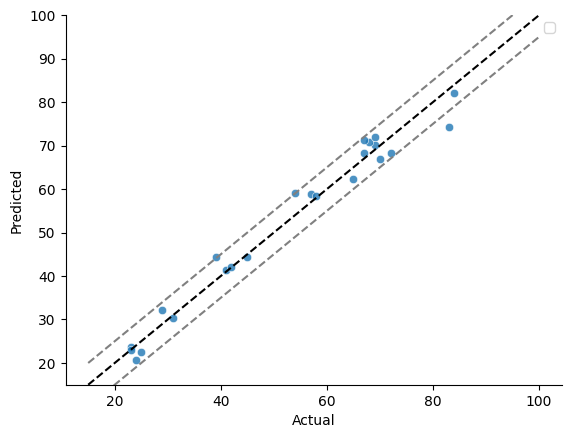

In [15]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [16]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[4, 0, 0, 0, 0, 0, 0],
       [0, 2, 0, 0, 0, 0, 0],
       [0, 0, 4, 0, 0, 0, 0],
       [0, 0, 0, 3, 0, 0, 0],
       [0, 0, 0, 1, 4, 2, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 2]])

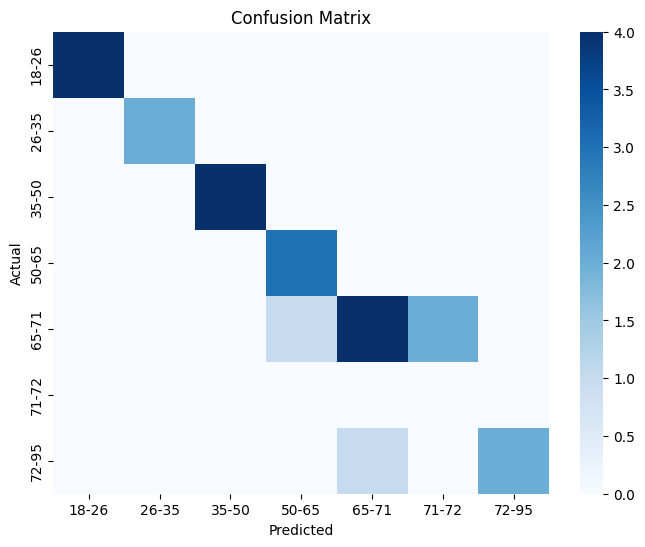

In [17]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [18]:
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_SMOTE_test.csv")
eigth_bins_test.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Sample,Experiment,Age
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.024511,-0.024499,-0.023623,-0.024472,-0.024526,-0.023199,-0.024432,SRR12604218,GSE157585,24.0
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.025282,-0.025088,-0.024710,-0.025252,-0.025311,-0.024447,-0.025087,SRR13759023,GSE167186,18.0
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.029983,-0.029799,-0.029041,-0.029934,-0.029985,-0.022886,-0.029776,SRR13759025,GSE167186,23.0
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.028779,-0.028634,-0.026764,-0.028774,-0.028772,-0.027571,-0.028812,SRR1555206,GSE60590,26.4
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.026766,-0.026488,-0.026991,-0.026722,-0.026784,-0.025465,-0.026577,SRR12604184,GSE157585,71.0


In [19]:
age_ranges_list=[18, 26, 35, 50, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(eigth_bins_test["Age"], age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-50', 'range': (35, 50), 'count': 8},
 {'label': '50-65', 'range': (50, 65), 'count': 9},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [20]:
X_test_untoached = eigth_bins_test.drop(columns=["Age"])
X_test_untoached.drop(columns=["Experiment", "Sample"], inplace=True)
y_test_untoached = eigth_bins_test["Age"]
seq_z_test = eigth_bins_test["Experiment"]

In [21]:
seq_z_test = pd.DataFrame(seq_z_test)
seq_z_test.columns = ["Experiment"]

In [22]:
# Make predictions
y_pred = seq_regressor.predict(X_test_untoached)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test_untoached, y_pred)
seq_results = pd.DataFrame({'Actual': y_test_untoached, 'Predicted': y_pred})
seq_mse

43.031219528628256

/tmp/ipykernel_8007/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


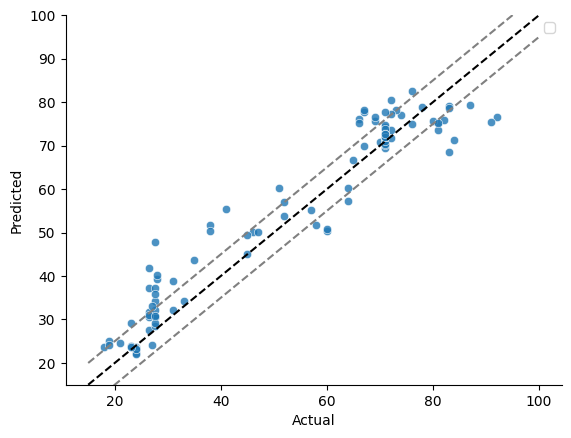

In [23]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

     Actual  Predicted Experiment
0      24.0  23.608512  GSE157585
1      18.0  23.749546  GSE167186
2      23.0  23.810633  GSE167186
3      26.4  37.177212   GSE60590
4      71.0  74.227273  GSE157585
..      ...        ...        ...
103    71.0  71.994536  GSE157585
104    23.0  23.714106  GSE167186
105    72.0  77.266073  GSE164471
106    71.0  72.637019  GSE157585
107    71.0  77.794009  GSE167186

[108 rows x 3 columns]


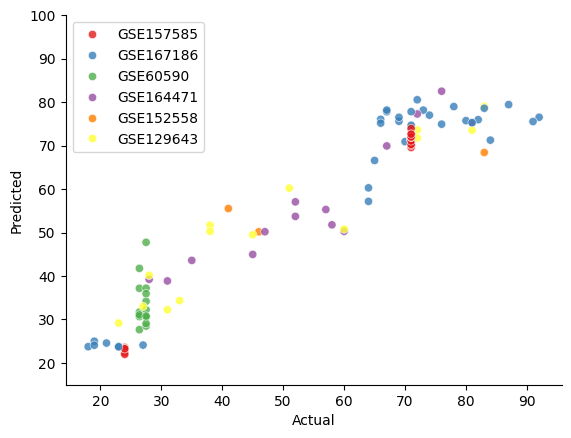

In [24]:
m.plot_results(results=seq_results, labels=seq_z_test)

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_results(results=seq_results, labels=seq_z_test, print_label='Experiment'):
# Define the custom palette
    custom_palette = {
        'GSE164471': 'red',
        'GSE157585': 'blue',
        'GSE167186': 'green',
        'GSE129643': 'purple',
        'GSE60590': 'orange',
        'GSE152558': 'yellow'
    }

    label_order = ['GSE164471', 'GSE157585', 'GSE167186', 'GSE129643', 'GSE60590', 'GSE152558']


    # Assuming 'print_label' is the column name for experiments
    experiment_column = labels[print_label].values
    results[print_label] = experiment_column
    print(results)

    # Create scatter plot with custom palette
    sns.scatterplot(x='Actual', y='Predicted', hue=print_label, data=results, palette=custom_palette, hue_order=label_order, alpha=0.8, edgecolor='w')

    plt.legend()
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.gca().set_ylim(bottom=15, top=100)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.show()

     Actual  Predicted Experiment
0      24.0  23.608512  GSE157585
1      18.0  23.749546  GSE167186
2      23.0  23.810633  GSE167186
3      26.4  37.177212   GSE60590
4      71.0  74.227273  GSE157585
..      ...        ...        ...
103    71.0  71.994536  GSE157585
104    23.0  23.714106  GSE167186
105    72.0  77.266073  GSE164471
106    71.0  72.637019  GSE157585
107    71.0  77.794009  GSE167186

[108 rows x 3 columns]


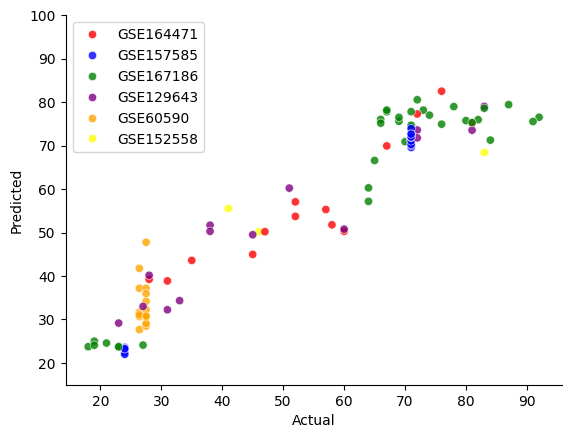

In [26]:
plot_results(results=seq_results, labels=seq_z_test)

In [27]:
c_y_test = pd.Series(y_test_untoached).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[12,  1,  0,  0,  0,  0,  0],
       [ 1, 14,  8,  0,  0,  0,  0],
       [ 0,  0,  3,  5,  0,  0,  0],
       [ 0,  0,  0,  9,  0,  0,  0],
       [ 0,  0,  0,  0,  3,  0,  6],
       [ 0,  0,  0,  0,  3, 13,  9],
       [ 0,  0,  0,  0,  1,  2, 18]])

In [28]:
acu = accuracy_score(c_y_test, c_y_pred)
acu

0.6666666666666666

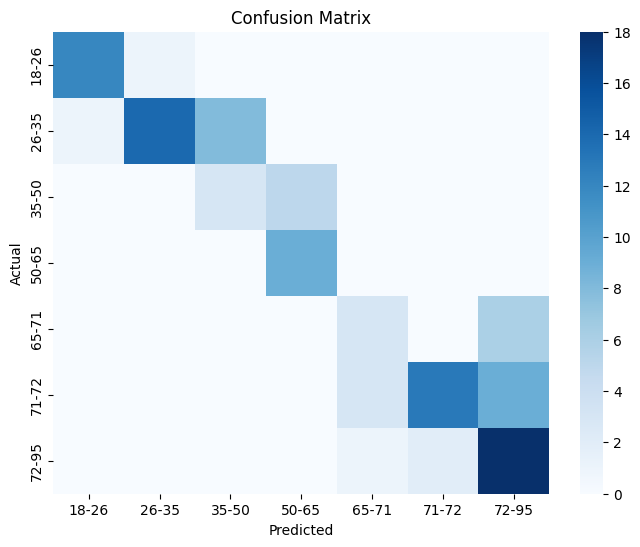

In [29]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test_untoached, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test_untoached, y_pred)

# Calculate R2
r2 = r2_score(y_test_untoached, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 43.031219528628256
RMSE: 6.559818559124045
MAE: 4.880503055045448
R2: 0.9140504937600199


In [31]:
explainer = shap.Explainer(seq_regressor)
shap_values = explainer.shap_values(X_test)
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=X_test.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
feature_imporance_df

,importance
ENSG00000243156.7,1.212992e+01
ENSG00000177606.6,5.034382e+00
ENSG00000156298.12,4.050692e+00
ENSG00000140548.9,3.214340e+00
ENSG00000103264.17,2.723651e+00
...,...
ENSG00000211842.1,1.353114e-06
ENSG00000065883.15,1.295337e-06
ENSG00000122359.17,1.226579e-06
ENSG00000214021.15,9.322329e-07


In [32]:
feature_file_name = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_2_SMOTE_SMOTE_8_seq_feature_importance.csv"
feature_imporance_df["abs"]= feature_imporance_df["importance"].abs()
feature_imporance_df.to_csv(feature_file_name)

In [33]:
import getting_threshold_genes as gtg

rank_genes = gtg.get_gene_rank(feature_file_name)
alpha = gtg.get_inflexion_point_from_gene_rank(rank_genes)
alpha

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/numpy/lib/polynomial.py:668: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


0.2430935688159489

In [41]:
feature_imporance_df.head(15)

,importance,abs
ENSG00000243156.7,12.129923,12.129923
ENSG00000177606.6,5.034382,5.034382
ENSG00000156298.12,4.050692,4.050692
ENSG00000140548.9,3.214340,3.214340
ENSG00000103264.17,2.723651,2.723651
ENSG00000285043.1,2.605298,2.605298
ENSG00000035664.11,2.584132,2.584132
ENSG00000262855.1,2.291662,2.291662
ENSG00000225840.2,2.059569,2.059569
ENSG00000164828.17,2.040997,2.040997


In [38]:
gene_names = [
    ("ENSG00000101892.11", "ATP1B4"),
    ("ENSG00000201766.1", "RNA5SP302"),
    ("ENSG00000127241.16", "MASP1"),
    ("ENSG00000277654.5", "AC087633.2"),
    ("ENSG00000145949.10", "MYLK4"),
    ("ENSG00000171055.14", "FEZ2"),
    ("ENSG00000198712.1", "MT-CO2"),
    ("ENSG00000164104.11", "HMGB2"),
    ("ENSG00000172399.5", "MYOZ2"),
    ("ENSG00000177548.12", "RABEP2"),
    ("ENSG00000089101.17", "CFAP61"),
    ("ENSG00000003989.17", "SLC7A2"),
    ("ENSG00000137700.17", "SLC37A4"),
    ("ENSG00000174227.15", "PIGG"),
    ("ENSG00000133020.4", "MYH8"),
    ("ENSG00000252262.1", "RNA5SP61"),
    ("ENSG00000234441.1", "AC105272.1"),
    ("ENSG00000247627.2", "MTND4P12"),
    ("ENSG00000100568.10", "VTI1B"),
    ("ENSG00000237973.1", "MTCO1P12"),
    ("ENSG00000178053.17", "MLF1"),
    ("ENSG00000134056.11", "MRPS36"),
    ("ENSG00000276045.3", "ORAI1"),
    ("ENSG00000007944.14", "MYLIP"),
    ("ENSG00000029725.16", "RABEP1"),
    ("ENSG00000145414.8", "NAF1"),
    ("ENSG00000257542.5", "OR7E47P"),
    ("ENSG00000163322.13", "ABRAXAS1"),
    ("ENSG00000134684.10", "YARS"),
    ("ENSG00000108349.16", "CASC3"),
    ("ENSG00000127184.12", "COX7C"),
    ("ENSG00000172456.17", "FGGY"),
    ("ENSG00000249780.1", "AC093809.1"),
    ("ENSG00000107890.16", "ANKRD26"),
    ("ENSG00000082153.17", "BZW1"),
    ("ENSG00000177606.6", "JUN"),
    ("ENSG00000160961.11", "ZNF333"),
    ("ENSG00000169926.10", "KLF13"),
    ("ENSG00000222922.1", "RNA5SP501"),
    ("ENSG00000104904.12", "OAZ1"),
    ("ENSG00000169083.16", "AR"),
    ("ENSG00000101400.5", "SNTA1"),
    ("ENSG00000172159.15", "FRMD3"),
    ("ENSG00000112531.16", "QKI"),
    ("ENSG00000229344.1", "MTCO2P12"),
    ("ENSG00000105048.16", "TNNT1"),
    ("ENSG00000123095.5", "BHLHE41"),
    ("ENSG00000125351.11", "UPF3B"),
    ("ENSG00000270388.1", "MTCO3P22"),
    ("ENSG00000004961.14", "HCCS"),
    ("ENSG00000243156.7", "MICAL3"),
    ("ENSG00000177606.6", "JUN"),
    ("ENSG00000156298.12", "TSPAN7"),
    ("ENSG00000140548.9", "ZNF710"),
    ("ENSG00000103264.17", "FBXO31"),
    ("ENSG00000285043.1", "ALDOA"),
    ("ENSG00000035664.11", "DAPK2"),
    ("ENSG00000262855.1", "AC012146.4"),
    ("ENSG00000225840.2", "AC010970.1"),
    ("ENSG00000164828.17", "SUN1"),
    ("ENSG00000234441.1", "AC105272.1"),
    ("ENSG00000166619.12", "BLCAP"),
    ("ENSG00000066855.15", "MTFR1"),
    ("ENSG00000076685.18", "NT5C2"),
    ("ENSG00000103353.15", "UBFD1"),
    ("ENSG00000102804.14", "TSC22D1"),
    ("ENSG00000235162.8", "C12orf75"),
    ("ENSG00000130714.15", "POMT1"),
    ("ENSG00000203685.9", "STUM"),
    ("ENSG00000156026.14", "MCU"),
    ("ENSG00000113916.17", "BCL6"),
    ("ENSG00000164879.6", "CA3"),
    ("ENSG00000140836.16", "ZFHX3"),
    ("ENSG00000206172.8", "HBA1"),
    ("ENSG00000123562.16", "MORF4L2"),
    ("ENSG00000089280.18", "FUS"),
    ("ENSG00000164104.11", "HMGB2"),
    ("ENSG00000131069.19", "ACSS2"),
    ("ENSG00000020577.13", "SAMD4A"),
    ("ENSG00000126214.21", "KLC1"),
    ("ENSG00000214078.12", "CPNE1"),
    ("ENSG00000107929.14", "LARP4B"),
    ("ENSG00000103145.10", "HCFC1R1"),
    ("ENSG00000168385.17", "SEPT2"),
    ("ENSG00000140545.14", "MFGE8"),
    ("ENSG00000100813.14", "ACIN1"),
    ("ENSG00000185271.8", "KLHL33"),
    ("ENSG00000004776.12", "HSPB6"),
    ("ENSG00000187186.14", "AL162231.1"),
    ("ENSG00000137497.17", "NUMA1"),
    ("ENSG00000250479.8", "CHCHD10"),
    ("ENSG00000221978.11", "CCNL2"),
    ("ENSG00000115364.13", "MRPL19"),
    ("ENSG00000252864.1", "RNA5SP278"),
    ("ENSG00000133020.4", "MYH8"),
    ("ENSG00000196465.10", "MYL6B"),
    ("ENSG00000077044.10", "DGKD"),
    ("ENSG00000223293.1", "RNA5SP270"),
    ("ENSG00000172159.15", "FRMD3"),
    ("ENSG00000003402.19", "CFLAR")
]



for gene_id, gene_name in gene_names:
    if gene_id in X_test.columns:
        X_test.rename(columns={gene_id: gene_name}, inplace=True)


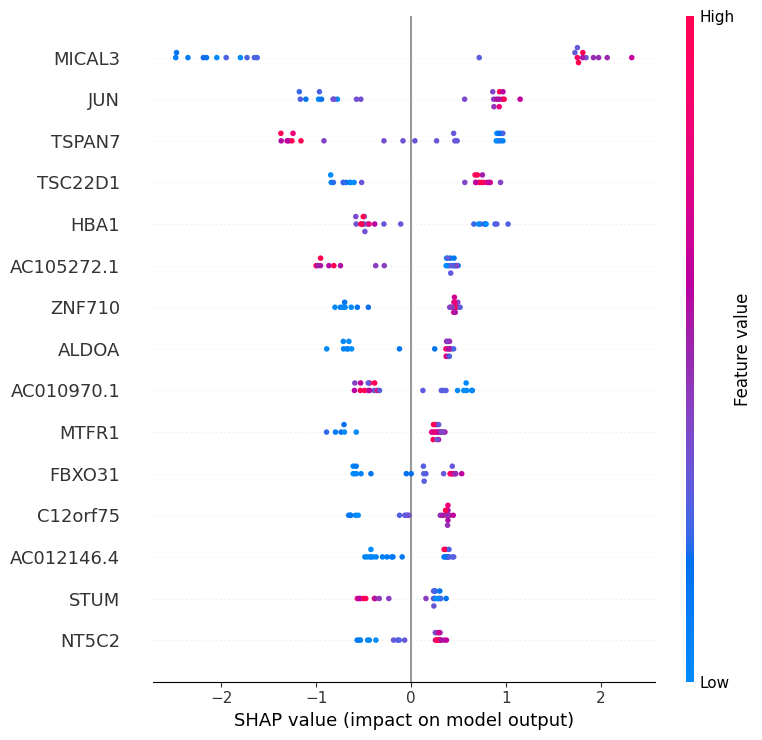

In [40]:
shap.summary_plot(shap_values, X_test, max_display=15)


In [37]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.614312318594637